# Proyecto Final — Ingeniería de Datos
## DataCommerce GT: Plataforma de Datos Integrada

**Integrantes:**
- Daniella Marissa Navarro Araniva
- Diego Alejandro Escobar Barahona

**Repositorio:** https://github.com/bapatata688/proyecto_final.git

---

Este notebook documenta el proceso técnico realizado en cada día del proyecto (arquitectura, extracción, calidad, modelado, carga y análisis).

---
# Día 1 — Comprensión del negocio y arquitectura

## 1. El problema de negocio

DataCommerce GT vende productos tecnológicos a través de 4 canales: tiendas físicas, comercio electrónico, ventas corporativas y WhatsApp.

Con el crecimiento de la empresa, la información quedó dispersa en distintos sistemas, lo que provoca que la gerencia no tenga reportes confiables ni oportunos, y que cada departamento genere resultados que no coinciden entre sí.

**Solución propuesta:** construir una plataforma de datos que integre todas las fuentes en un único Data Warehouse, de manera que exista una sola fuente de verdad para generar los indicadores que la gerencia necesita.

## 2. Revisión de archivos e identificación de problemas

Se hizo una exploración inicial de cada fuente (filas, columnas, tipos de dato) para detectar de antemano:
- Columnas con valores nulos o faltantes.
- Registros duplicados.
- Formatos inconsistentes entre fuentes (fechas, nombres, categorías, IDs).
- Reglas de limpieza necesarias, para no limpiar a ciegas en el Día 2.

## 3. Arquitectura de la solución

```
[Fuentes de datos]
  CSV (Ventas) | Excel (Productos) | JSON (Clientes) | SQLite (Inventario) | API REST (Campañas)
        │
        ▼
[Extracción] → scripts Python (pandas, requests, sqlite3, openpyxl)
        │
        ▼
[Staging] → datos crudos unificados, sin transformar (para trazabilidad)
        │
        ▼
[Transformación / Calidad de datos]
  - Limpieza (duplicados, nulos, formatos)
  - Estandarización (nombres, categorías, fechas, monedas)
  - Validación de reglas de negocio
        │
        ▼
[Data Warehouse] → modelo dimensional (esquema estrella) en BigQuery
        │
        ▼
[Consumo] → consultas SQL, KPIs con Pandas, Dashboard
```

**Stack tecnológico:** Python + Pandas (ETL), BigQuery (Data Warehouse), SQL (consultas analíticas), HTML/Chart.js (dashboard).

**Por qué esta arquitectura:**
- Se separa staging de transformación para no perder los datos crudos originales.
- El pipeline se diseña para ser reproducible: debe poder ejecutarse de nuevo sin intervención manual.
- El modelo dimensional facilita las consultas analíticas y el cálculo de KPIs para gerencia.

## 4. Modelo relacional preliminar

**Entidades identificadas:** Cliente, Producto, Venta, Inventario, Tienda/Canal, Campaña.

**Relaciones esperadas:**
- Un Cliente puede tener muchas Ventas (1:N)
- Un Producto puede aparecer en muchas Ventas (1:N)
- Un Producto tiene inventario en varias Tiendas (N:M, vía Inventario)
- Una Campaña puede influir en varias Ventas

## 5. Plan del ETL

**Extracción por fuente:** CSV → `pandas.read_csv()` · Excel → `pandas.read_excel()` · JSON → `pandas.read_json()` · SQLite → `sqlite3`/`pandas.read_sql()` · API REST → `requests.get()`.

**Transformaciones esperadas:** eliminar duplicados por clave primaria, normalizar fechas a `YYYY-MM-DD`, estandarizar nombres/categorías, definir regla para nulos, unificar IDs entre fuentes.

**Carga:** primero a staging (datos crudos), luego transformación y carga al modelo dimensional.

---
# Día 2 — Extracción, Calidad y Limpieza

## Qué se hizo

Se trabajó directamente sobre los 5 archivos entregados por el instructor (`ventas.csv`, `productos.xlsx`, `clientes.json`, `inventario.db`, `api_marketing_response.json`). `inventario.db` resultó tener **2 tablas** (`inventario_actual` y `movimientos_inventario`), así que el pipeline extrae y limpia **6 tablas** en total.

## Estructura de archivos

```
dia_2/
├── config.py                # rutas, variables de entorno, logging
├── extract.py                # 6 funciones de extracción (una por tabla)
├── quality.py                 # perfilado de calidad + integridad referencial
├── clean.py                   # 6 funciones de limpieza (una por tabla)
├── ejecutar_extraccion.py
├── ejecutar_perfilado.py
├── ejecutar_limpieza.py
├── data/
│   ├── raw/          # archivos originales entregados por el instructor
│   ├── interim/       # extraído tal cual, sin limpiar (parquet)
│   └── processed/     # limpio y estandarizado (parquet), listo para día 3
└── reports/
    └── hallazgos_calidad.md
```

## Las 6 tablas y su fuente real

| Tabla | Fuente | Origen |
|---|---|---|
| ventas | CSV | `data/raw/ventas.csv` |
| productos | Excel | `data/raw/productos.xlsx` |
| clientes | JSON | `data/raw/clientes.json` |
| inventario_actual | SQLite (`inventario_actual`) | `data/raw/inventario.db` |
| movimientos_inventario | SQLite (`movimientos_inventario`) | `data/raw/inventario.db` |
| campanas | API REST (mock si no hay URL) | `data/raw/api_marketing_response.json` |

**Nota sobre volumen:** los archivos entregados tienen solo encabezados y unas pocas filas de ejemplo. Ningún script asume un número fijo de filas: funcionarán igual con el volumen completo, siempre que se mantengan los mismos nombres de columna.

## Cómo se corre el pipeline

```bash
python ejecutar_extraccion.py    # lee data/raw/        -> data/interim/*.parquet
python ejecutar_perfilado.py     # perfila data/interim/ -> reports/hallazgos_calidad.md
python ejecutar_limpieza.py      # limpia data/interim/  -> data/processed/*.parquet
```

## Hallazgos de calidad (proceso, no resultado de negocio)

- **`ventas.fecha_venta` mezcla 3 formatos** en la misma columna: `2026-07-01` (AAAA-MM-DD), `01/07/2026` (DD/MM/AAAA) y `2026/07/02` (AAAA/MM/DD).
- **`clientes.municipio` llega como string vacío (`""`)**, no nulo, para un registro. Un perfilador de nulos estándar no lo detecta porque `""` no es `NaN`.
- **Integridad referencial:** `cliente_id 504` aparece en una venta pero no existe en `clientes.json` — huérfano detectado automáticamente.
- Por observación directa: `producto_id 2004` aparece en productos y en una venta, pero no tiene registro en `inventario_actual` — pendiente de confirmar con el instructor cuando llegue el volumen completo.

## Decisión técnica destacada: parseo de fechas mixtas

`pd.to_datetime(..., format="mixed", dayfirst=True)` parece la solución obvia, pero al probarla contra estos datos reales **produce fechas incorrectas**: además de resolver la ambigüedad de `01/07/2026`, también invierte mes y día en fechas año-primero como `2026-07-01`.

La solución en `clean.py` detecta el formato por la posición del año (nunca ambigua, siempre 4 dígitos):
- Año primero (`AAAA-MM-DD` o `AAAA/MM/DD`) → se parsea directo, sin asumir día primero.
- Año al final (`DD/MM/AAAA`) → sí es ambiguo, se asume día primero (convención de Guatemala).

## Reglas de limpieza aplicadas y su justificación

| Tabla | Regla | Justificación |
|---|---|---|
| ventas | Elimina duplicados por venta_id | Un id de venta no puede repetirse |
| ventas | Normaliza fecha_venta (3 formatos mezclados) | Ver decisión técnica arriba |
| ventas | cantidad/descuento negativos → valor absoluto | No existen ventas ni descuentos negativos |
| ventas | total_venta recalculado | No arrastrar errores de captura del archivo original |
| productos | Elimina duplicados por producto_id | Un producto no puede repetirse en el catálogo |
| productos | Recorta espacios extra en texto | Error común de captura manual |
| productos | categoría/subcategoría nulas → "Sin Categoría" | No perder el producto en reportes agrupados |
| productos | precio_lista no convertible → se descarta la fila | No se puede vender un producto sin precio |
| clientes | Elimina duplicados por cliente_id | Un cliente no puede repetirse |
| clientes | municipio `""` → nulo | String vacío no es un municipio válido |
| clientes | fecha_registro normalizada | Consistencia con el resto de fechas |
| inventario_actual | Elimina duplicados por (producto_id, bodega) | Una bodega no puede tener 2 registros del mismo producto |
| inventario_actual | existencia negativa → 0 | El stock físico nunca es negativo |
| movimientos_inventario | Elimina duplicados por id | Es la llave primaria del movimiento |
| movimientos_inventario | cantidad negativa → valor absoluto | La dirección la indica `tipo`; cantidad es la magnitud |
| campañas | Elimina duplicados por campaña_id | Una campaña no puede repetirse |
| campañas | métricas negativas → 0 | Son conteos o gasto, nunca negativos |

## Chequeo automático (self-check)

`ejecutar_limpieza.py` valida, después de limpiar cada tabla, que sus propias reglas se cumplieron (sin duplicados por llave, sin negativos donde no debería haberlos). Si algo se rompe, el script falla con un `AssertionError` explícito en vez de guardar datos incorrectos silenciosamente.

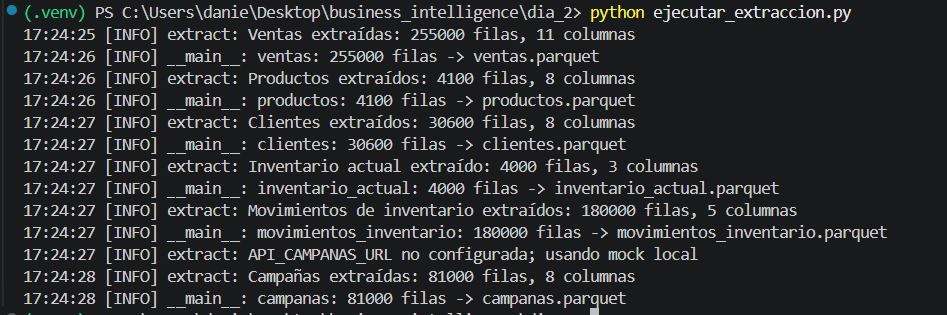
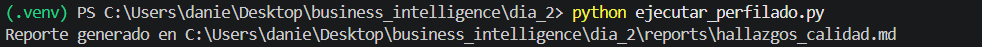
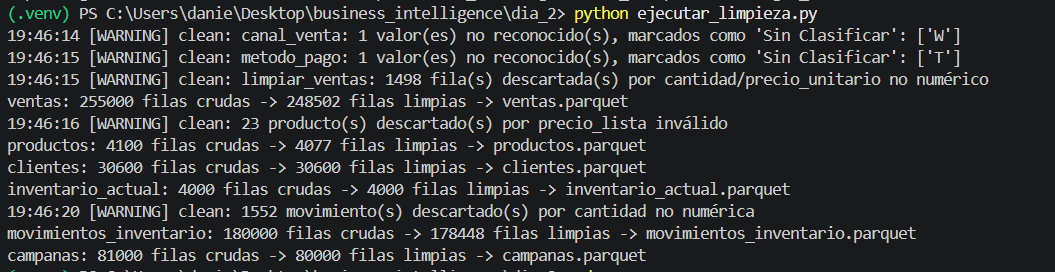



---
# Día 3 — Modelado Dimensional y Carga al Data Warehouse

## Objetivo del día

Tomar los datos limpios del Día 2, diseñar el modelo dimensional (esquema estrella) y cargarlo al Data Warehouse en BigQuery (`dw_datacommerce`).

## Qué se hizo

1. **Diseño del modelo estrella:** 7 tablas de dimensión y 4 tablas de hechos.
2. **Construcción de las tablas (`modelado.py`):** lee los Parquet limpios del Día 2, genera llaves sustitutas (surrogate keys) donde no existía un ID de origen (canal, método de pago, plataforma, bodega), arma las dimensiones y las tablas de hechos.
3. **Carga a BigQuery (`cargar_bigquery.py`):** sube cada tabla al dataset `dw_datacommerce`, reemplazando el contenido en cada corrida (`WRITE_TRUNCATE`) para que el pipeline sea reproducible.
4. **Orquestador (`ejecutar_dia3.py`):** corre los dos pasos anteriores con un solo comando.

## Estructura de archivos

| Archivo | Función |
|---|---|
| `config.py` | Configuración central: PROJECT_ID, dataset, rutas y clave de credenciales |
| `esquema_dw.sql` | DDL de las 11 tablas del modelo estrella |
| `modelado.py` | Construye dimensiones y hechos a partir de los datos limpios del Día 2 |
| `cargar_bigquery.py` | Sube las tablas generadas a BigQuery |
| `ejecutar_dia3.py` | Orquestador |
| `diagrama_modelo_estrella.svg` | Diagrama visual del modelo estrella |
| `diccionario_datos.md` | Diccionario de datos: cada tabla, columna, tipo y descripción |

## Cómo se corre

```bash
pip install google-cloud-bigquery pandas pyarrow --break-system-packages

# 1. Crear las tablas en BigQuery con el esquema correcto (una sola vez):
#    pegar esquema_dw.sql en BigQuery -> "Consulta en SQL"
# 2. Colocar la clave de la cuenta de servicio como credenciales_bigquery.json
# 3. Correr el pipeline completo:
python ejecutar_dia3.py
```

## Decisiones técnicas

- **Cliente huérfano:** la venta con `cliente_id 504` no tenía coincidencia en la tabla de clientes de origen. En vez de descartar la venta, se creó el registro `cliente_key = -1` ("Cliente desconocido") en `dim_cliente`, para conservar el ingreso registrado sin romper el JOIN.
- **`dim_sucursal` genérica:** no se recibió un catálogo real de sucursales (nombres, direcciones); la dimensión se construyó solo con el `sucursal_id` disponible en las ventas, con nombres genéricos ("Sucursal 1/2/3"). Pendiente de enriquecer si aparece la fuente real.
- **Llaves sustitutas para catálogos pequeños:** canal de venta, método de pago, plataforma y bodega llegaban como texto libre dentro de las tablas de hechos; se generaron dimensiones tipo catálogo con llave autogenerada, evitando texto repetido en los hechos.

## Resultado

11 tablas cargadas en `dw_datacommerce`: `dim_producto`, `dim_cliente`, `dim_sucursal`, `dim_canal`, `dim_metodo_pago`, `dim_plataforma`, `dim_bodega`, `fact_ventas`, `fact_movimiento_inventario`, `fact_inventario_existencia`, `fact_marketing`.

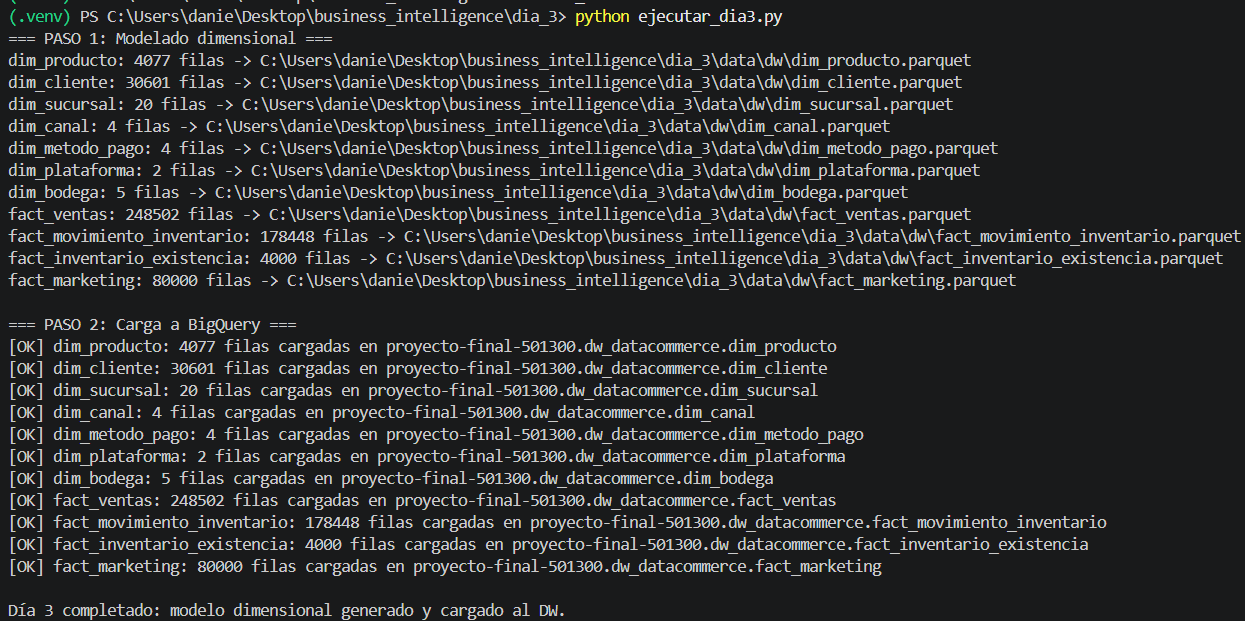
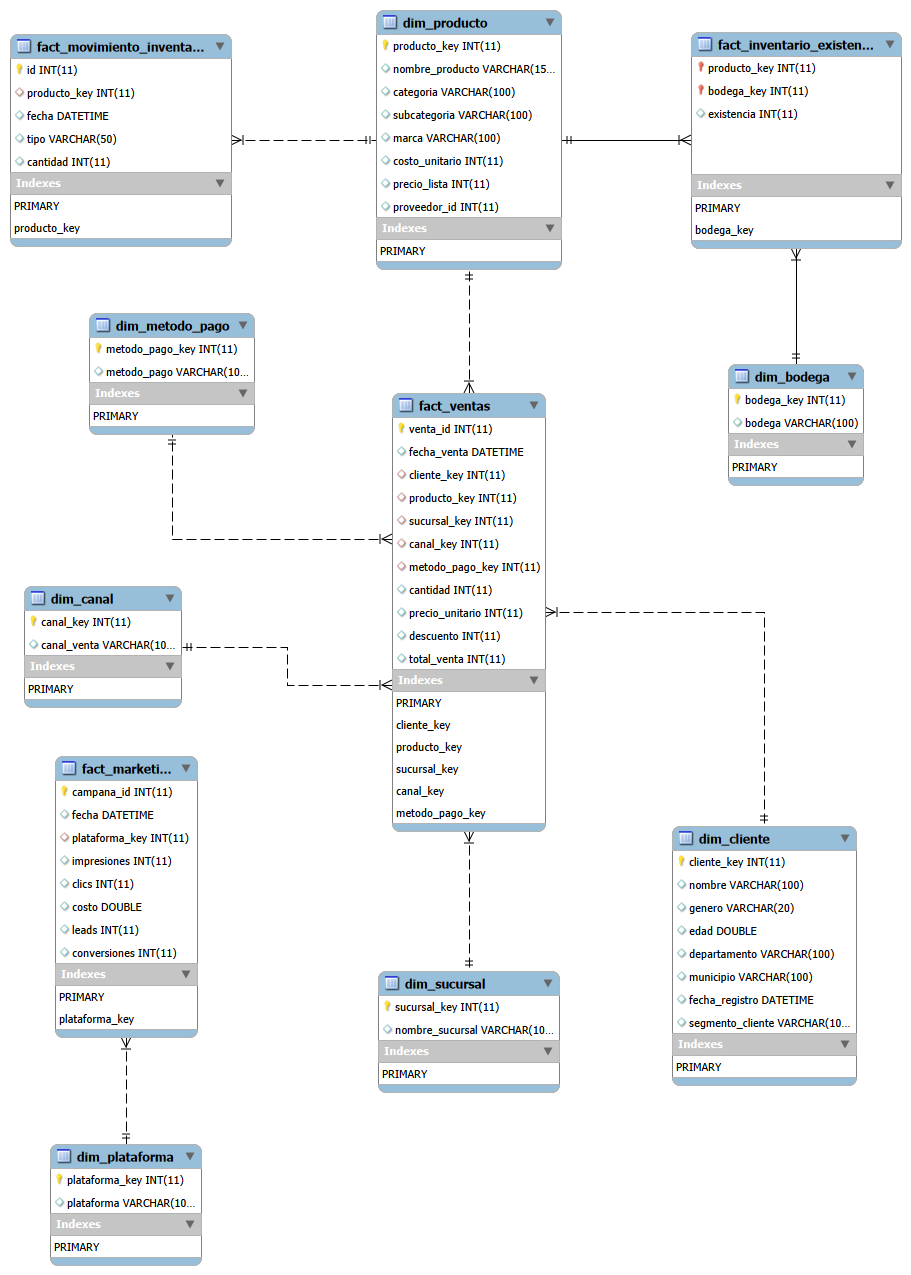
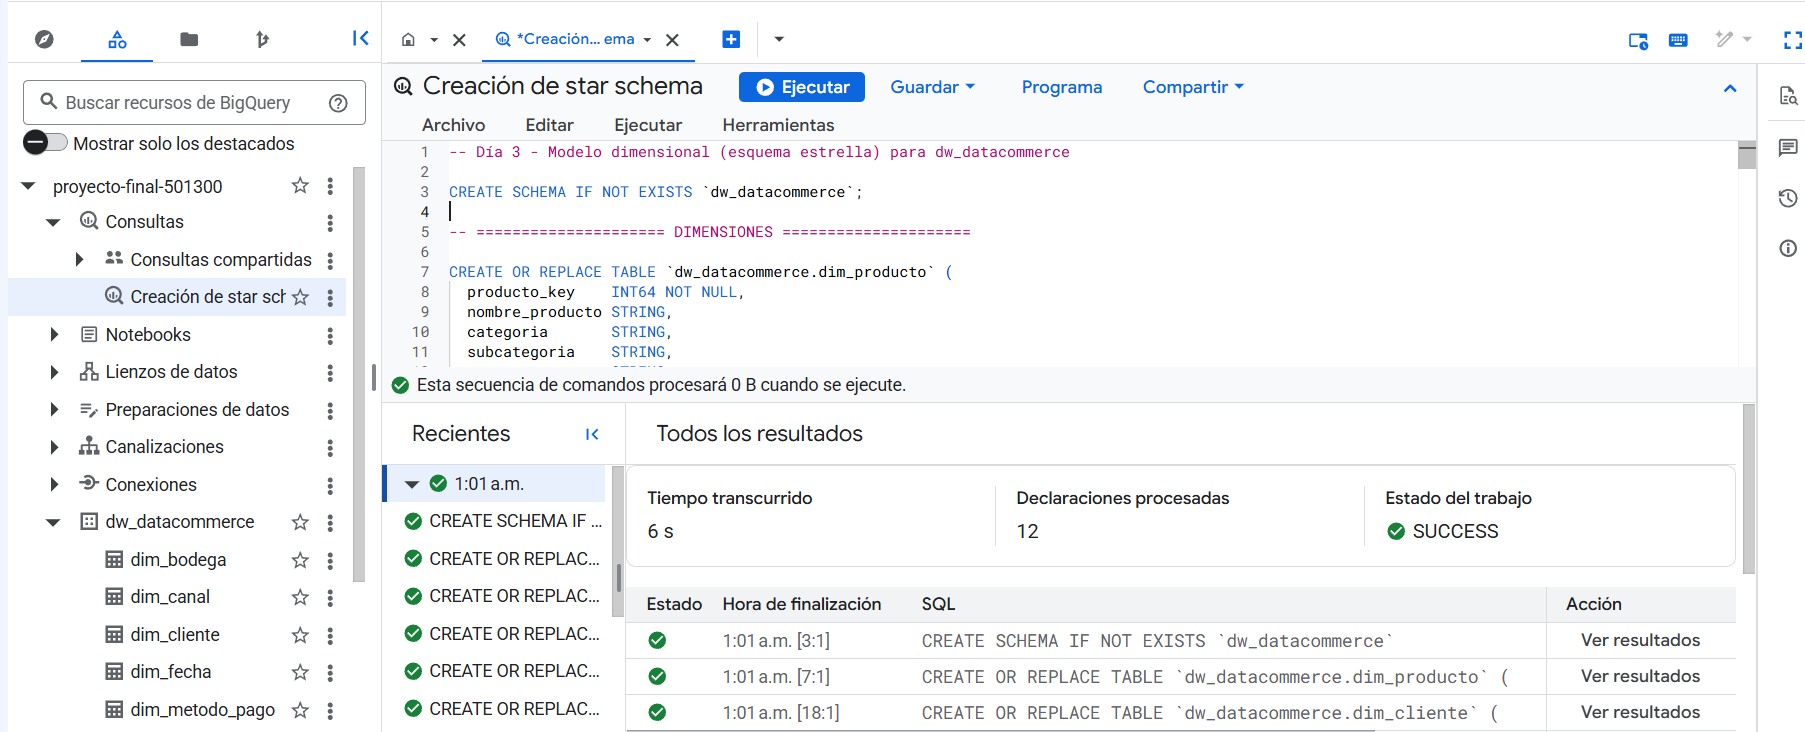

---
# Día 4 — Consultas SQL, KPIs con Pandas y Gráficos

## Objetivo del día

Consultar el Data Warehouse construido en el Día 3, calcular indicadores de negocio (KPIs) con Pandas, validarlos y generar los gráficos de apoyo al dashboard.

## Qué se hizo

1. **Consultas SQL analíticas (`consultas_sql.sql`):** 8 consultas directas sobre las tablas de BigQuery del Día 3.
2. **Cálculo de KPIs con Pandas (`kpis.py` + `calcular_kpis.py`):** se trae cada tabla desde BigQuery a un DataFrame y se calculan los indicadores con Pandas, como pide el objetivo del curso. Los resultados se guardan como CSV en `data/kpis/`, más un `kpis_resumen.json` consolidado que usa el dashboard del Día 5.
3. **Gráficos (`graficos.py`):** a partir de esos CSV, se generan 6 gráficos PNG en `graficos/`.
4. **Orquestador (`ejecutar_dia4.py`):** corre el cálculo de KPIs y la generación de gráficos con un solo comando.

## Estructura de archivos

| Archivo | Función |
|---|---|
| `config.py` | Configuración central (reutiliza la clave del Día 3) |
| `consultas_sql.sql` | 8 consultas SQL analíticas |
| `kpis.py` | Funciones puras de cálculo de KPIs (reciben DataFrames, se pueden probar sin BigQuery) |
| `calcular_kpis.py` | Trae las tablas desde BigQuery, calcula cada KPI y exporta CSV + `kpis_resumen.json` |
| `graficos.py` | Lee los CSV y genera los gráficos PNG |
| `ejecutar_dia4.py` | Orquestador |

## KPIs calculados 

1. Ventas totales y ticket promedio por canal de venta
2. Top productos por unidades y monto vendido
3. Ventas totales por sucursal
4. Método de pago más usado
5. Top clientes por monto de compra
6. Existencia actual de inventario por producto y bodega
7. Desempeño de campañas de marketing por plataforma: CTR, costo por lead, tasa de conversión
8. Movimientos de inventario por tipo (entradas vs. salidas)

## Cómo se corre

```bash
pip install google-cloud-bigquery pandas pyarrow matplotlib --break-system-packages
python ejecutar_dia4.py
```

## Validación de resultados

Cada KPI calculado con Pandas corresponde a una de las consultas SQL de `consultas_sql.sql`; se validó corriendo la consulta en BigQuery y comparando el resultado contra el CSV generado en `data/kpis/`, sobre los mismos datos de muestra.

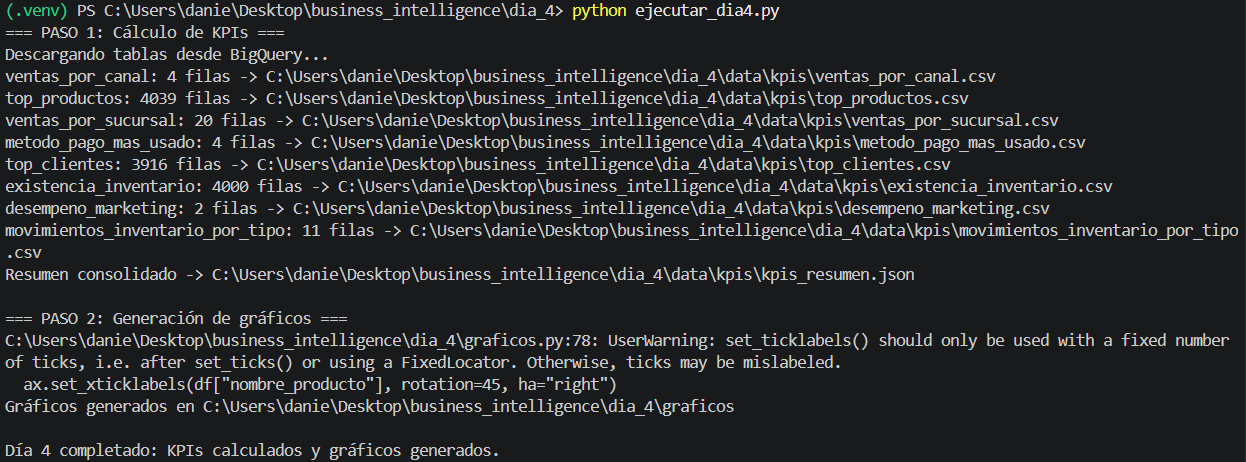
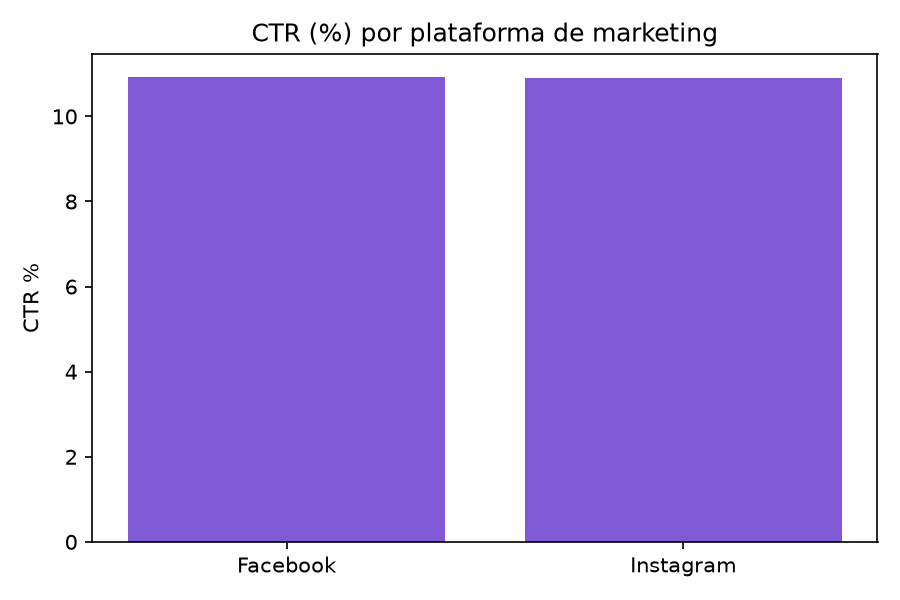
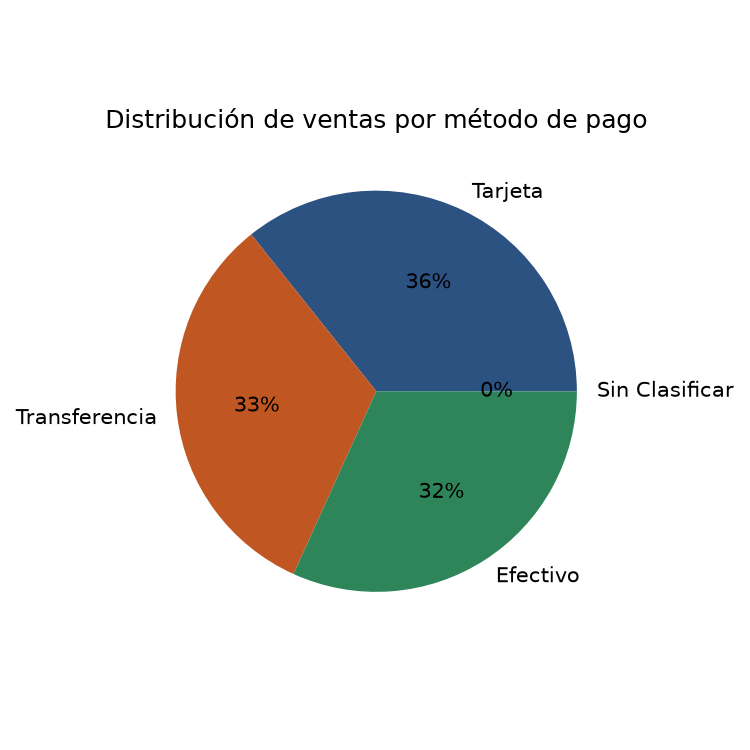
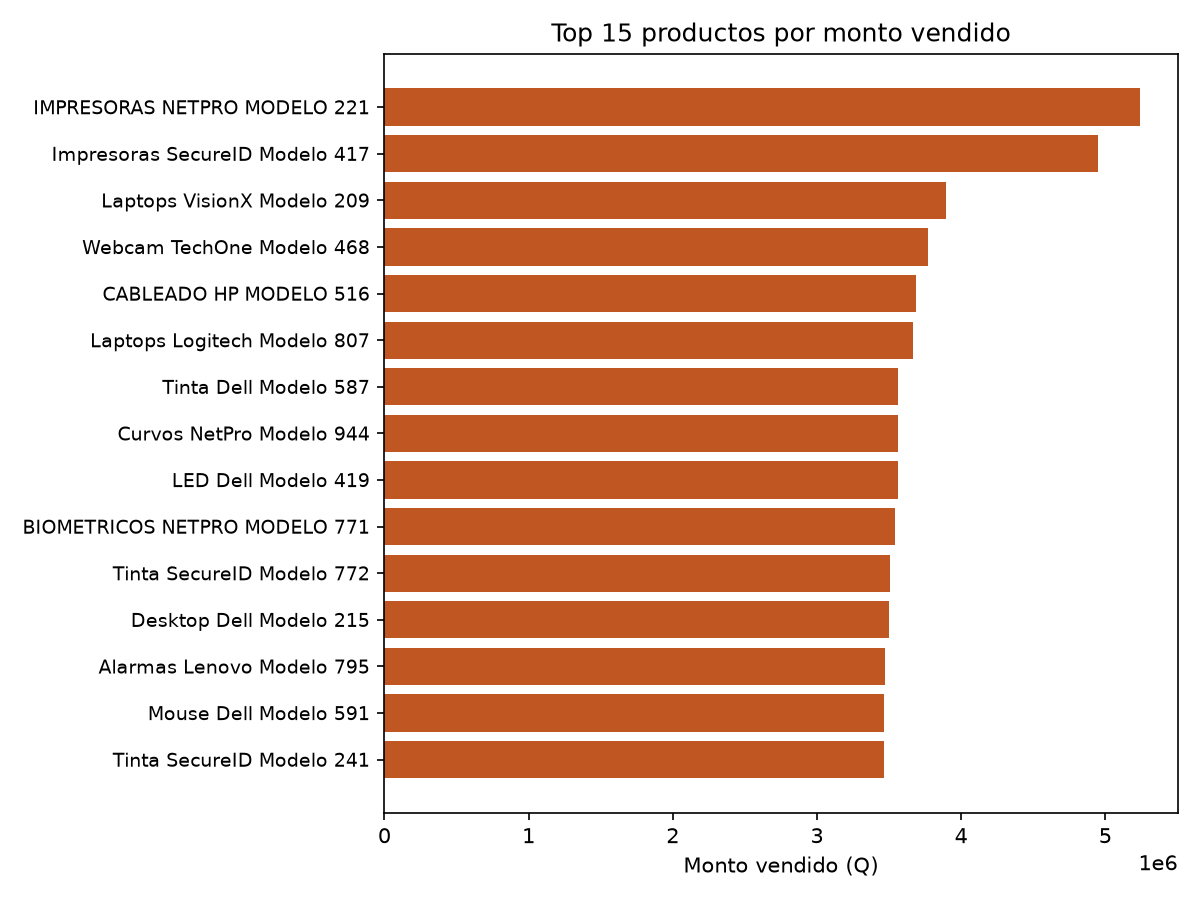
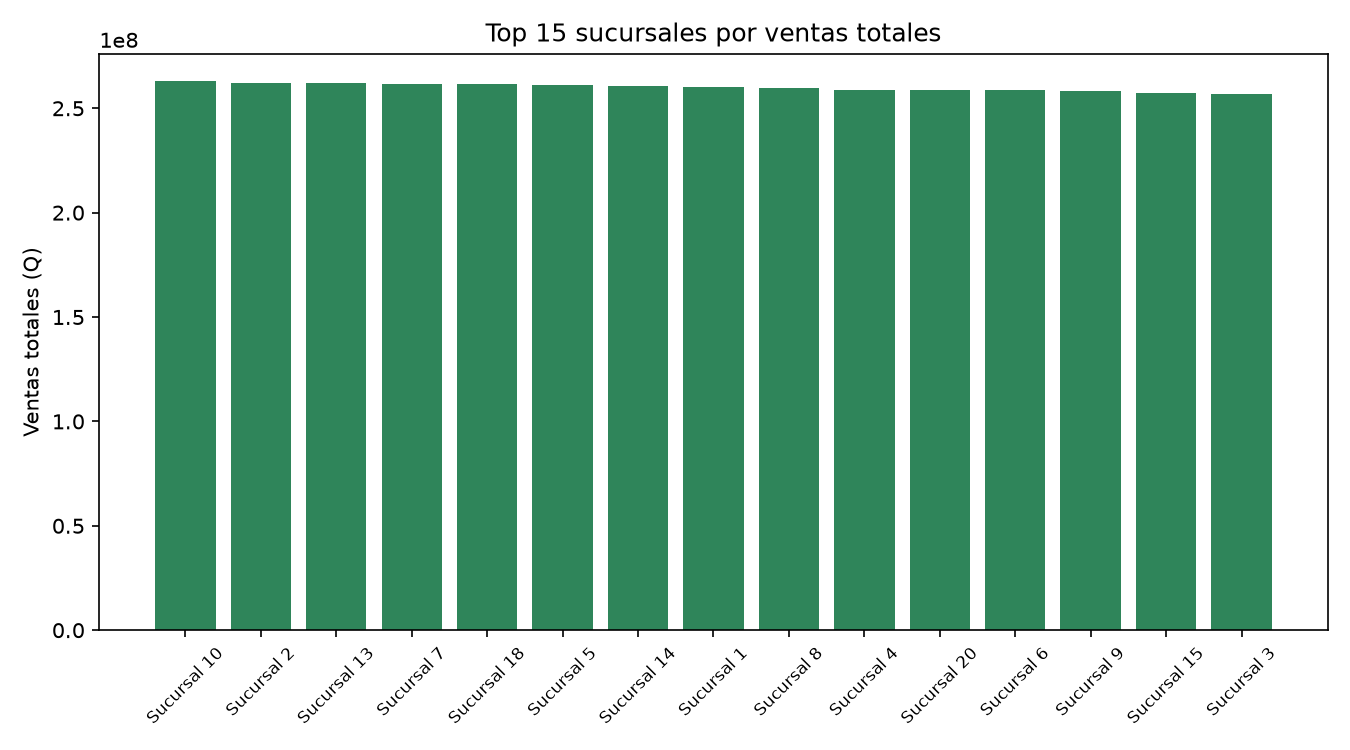
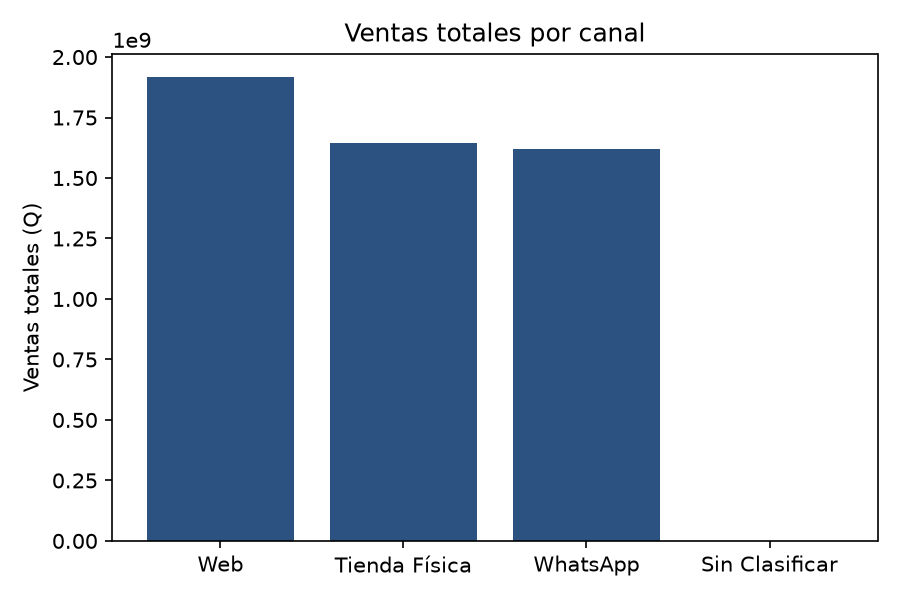

---
# Día 5 — Documentación Final y Dashboard 

## Objetivo del día

Cerrar el proyecto con los entregables orientados a negocio: dashboard interactivo, informe ejecutivo, presentación para la defensa técnica y guía de preguntas frecuentes.

## Qué se hizo

### Dashboard interactivo (`dashboard.html`)

Dashboard con tarjetas de KPI, gráficos (Chart.js) y tablas, construido a partir de los indicadores del Día 4. Se puede abrir directamente en el navegador sin necesidad de servidor.

### Dashboard automático (`actualizar_dashboard.py`)

Este es el punto clave del Día 5: el dashboard no tiene los números escritos a mano. Se diseñó para que se actualice solo cuando cambien los datos, sin editar código:

1. `calcular_kpis.py` (Día 4) genera `data/kpis/kpis_resumen.json`, un resumen consolidado de los 8 KPIs.
2. Dentro de `dashboard.html`, el bloque de datos está delimitado por dos comentarios marcadores: `// ===DATOS_INICIO===` y `// ===DATOS_FIN===`.
3. `actualizar_dashboard.py` lee `kpis_resumen.json`, renombra las columnas al formato que espera el dashboard, y reemplaza únicamente el contenido entre esos dos marcadores dentro de `dashboard.html`, dejando el resto del archivo (estilos, gráficos, estructura) intacto.

**Flujo completo**

```bash
# 1. Reemplazar los archivos crudos en dia_2/data/raw con los oficiales
# 2. Re-correr la cadena completa del pipeline:
python ejecutar_extraccion.py      # Día 2, parte 1
python ejecutar_limpieza.py        # Día 2, parte 2
python ejecutar_dia3.py            # Día 3 (recarga BigQuery)
python ejecutar_dia4.py            # Día 4 (recalcula KPIs + regenera kpis_resumen.json)

# 3. Un solo comando más y el dashboard queda al día:
python actualizar_dashboard.py
```


## Dashboard interactivo
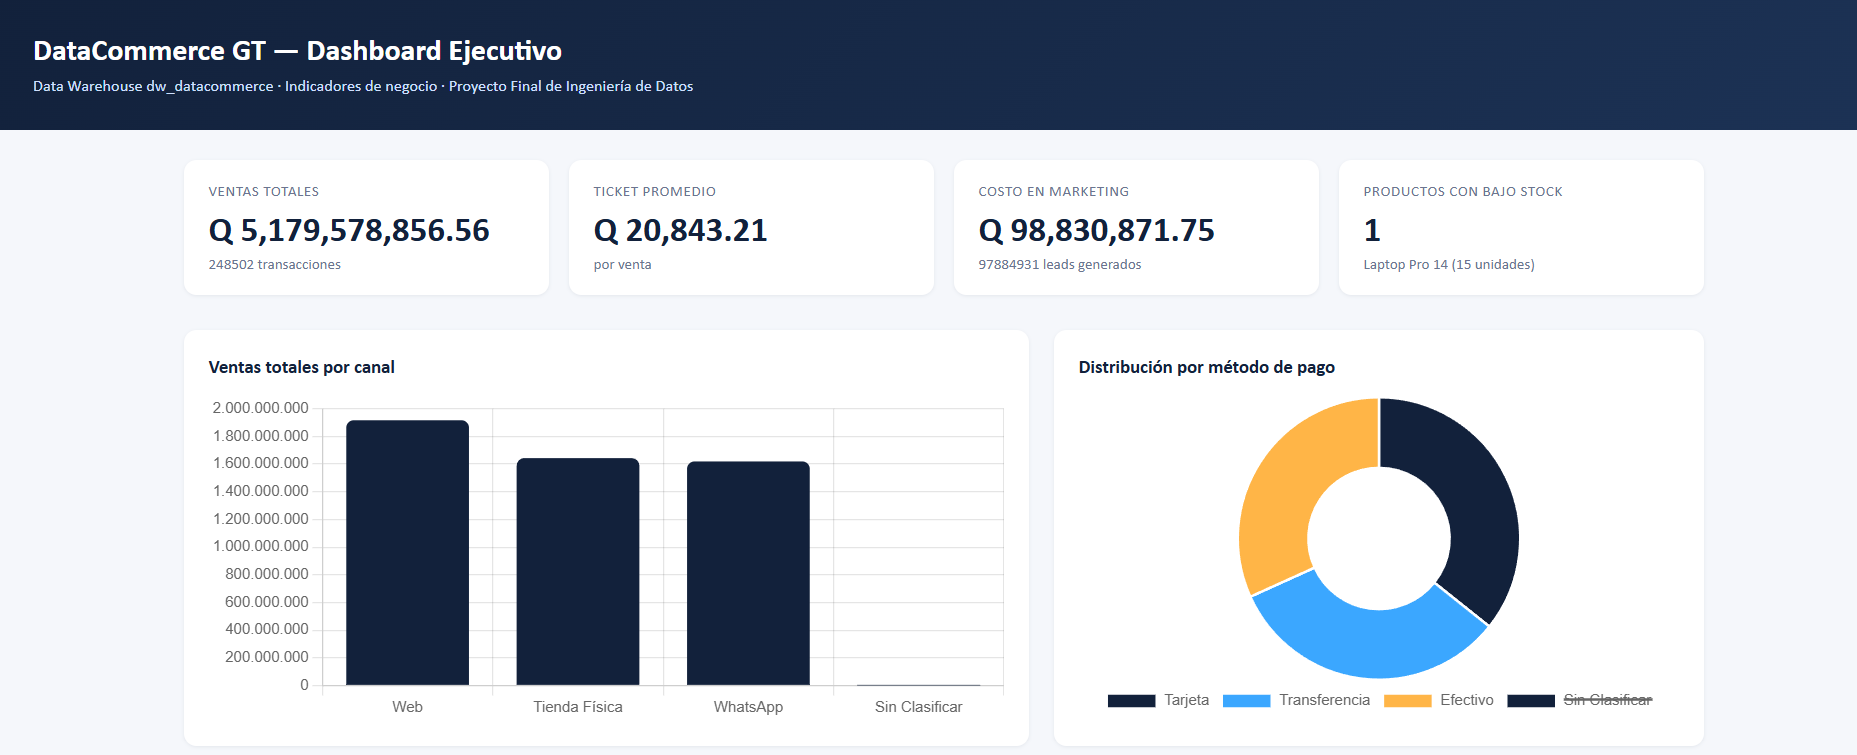
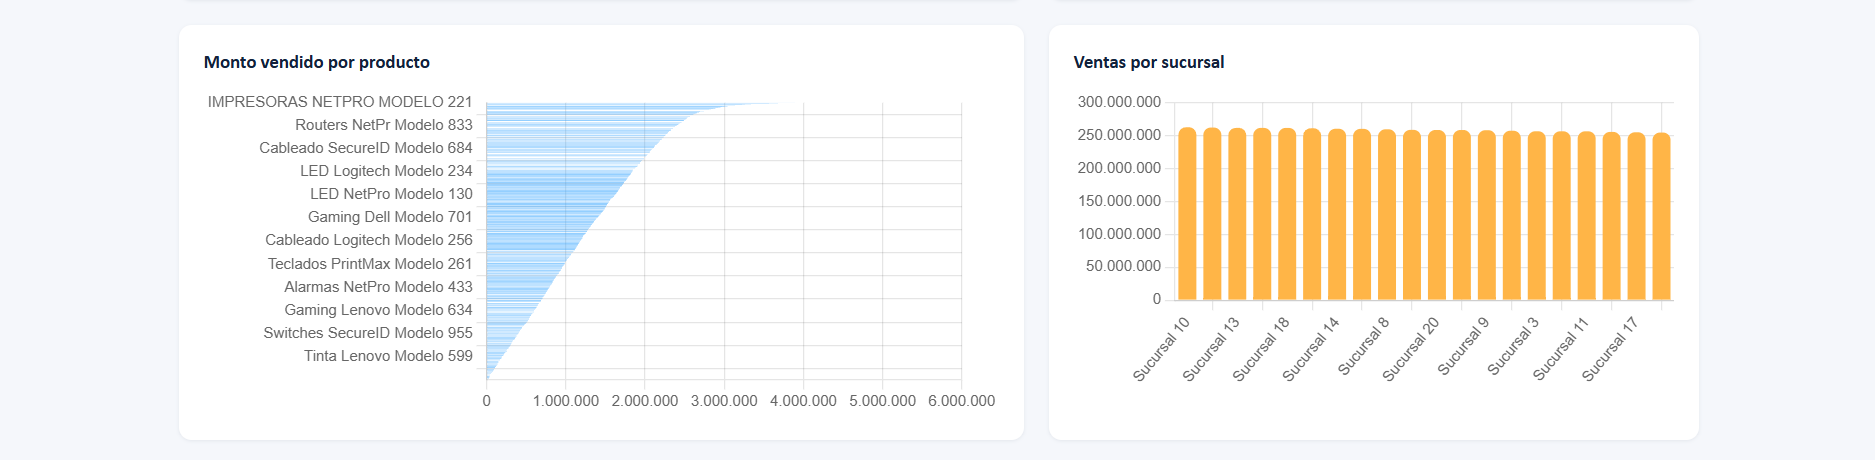
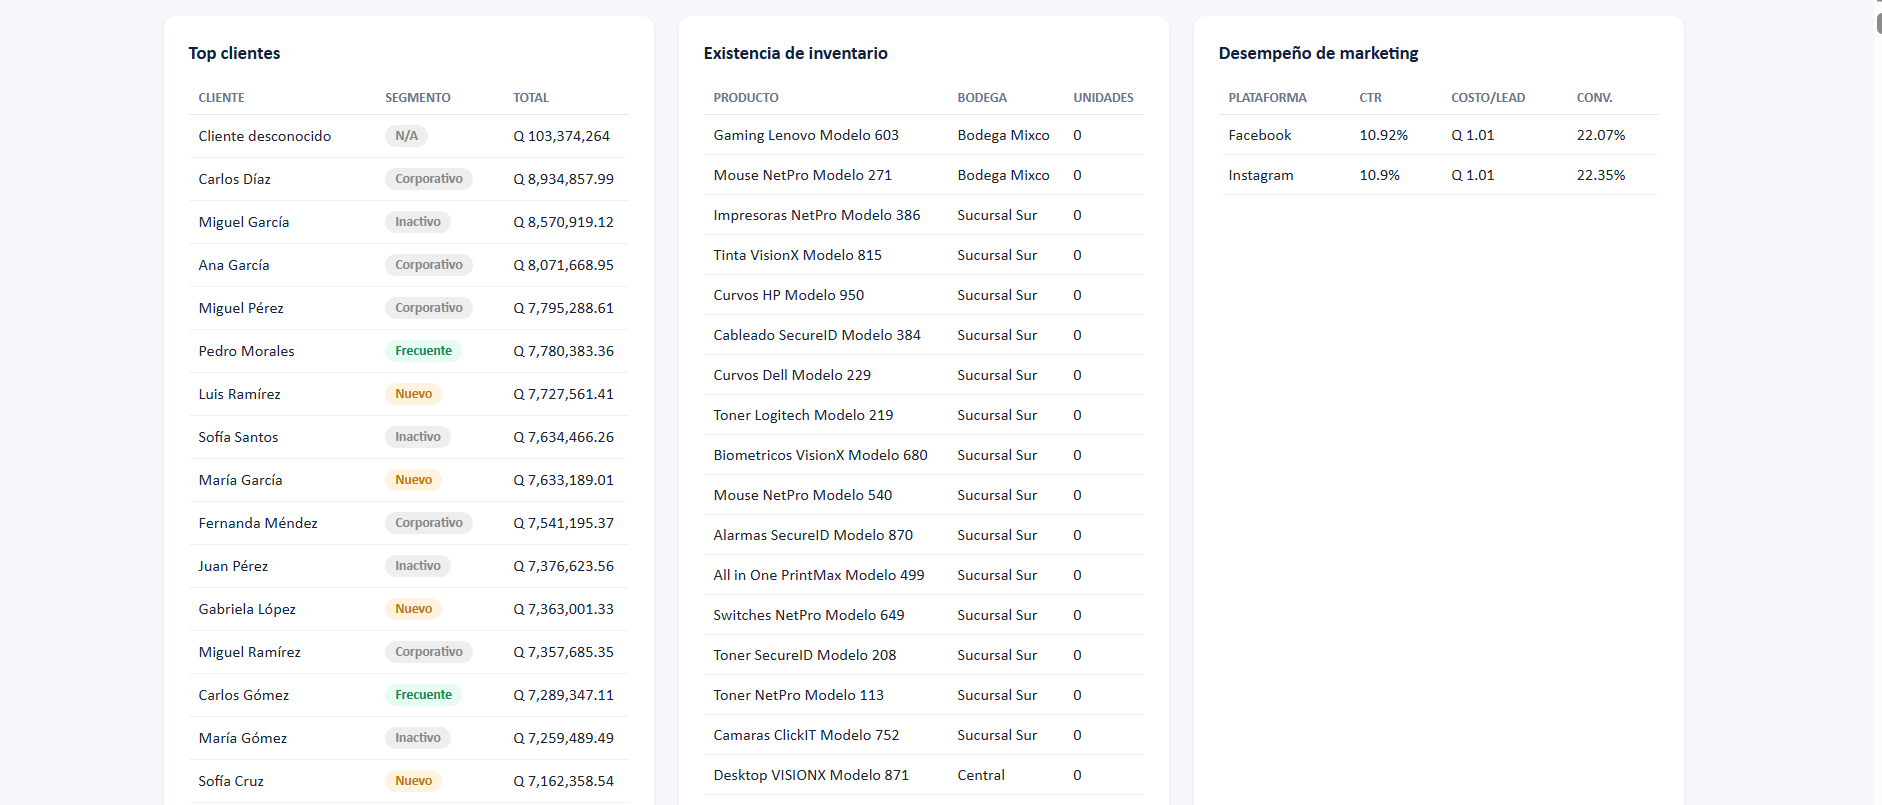

---
# Conclusiones

## Validación del pipeline a escala real

El diseño de los Días 1 a 5 se construyó y probó inicialmente con una muestra de pocas filas por fuente. Al recibir el volumen oficial (255,000 ventas, 4,100 productos, 30,600 clientes), el pipeline completo — extracción, calidad, limpieza, modelado, carga y KPIs — se ejecutó de nuevo sin cambios de arquitectura, confirmando que el diseño reproducible planteado desde el Día 1 cumplió su objetivo: los mismos scripts que corrieron con 5 filas corrieron con cientos de miles.

## Hallazgos de calidad que solo aparecieron con el volumen real

La muestra inicial no alcanzaba a mostrar varios problemas que sí aparecieron con los datos oficiales, y que se fueron resolviendo directamente en `clean.py`:

- **`clientes.edad`** con el valor `"N/A"` como texto en vez de nulo.
- **`ventas.cantidad` y `ventas.precio_unitario`** con valores no numéricos en 1,500 filas, que se descartaron y quedaron documentados con advertencia.
- **`productos.precio_lista` y `costo_unitario`** con valores negativos (error de captura), corregidos a valor absoluto.
- **Categorías de texto libre sin estandarizar**: `canal_venta`, `metodo_pago` y `plataforma` llegaban con decenas de variantes de la misma categoría (`Facebook`, `facebook`, `FB`, `Meta`, `FACEBOOK ADS`; `Tarjeta`, `TC`, `Visa`, `CREDITO`, etc.), resuelto con un diccionario de normalización que agrupa alias en una categoría canónica.
- **Productos con existencia en cero**: al filtrar los de menor stock, varios ya están en quiebre real, no solo en riesgo — un hallazgo que pasa directo al informe ejecutivo.

Cada uno de estos casos se resolvió sin modificar la arquitectura del pipeline: los cambios se aplicaron únicamente en las funciones de limpieza correspondientes, y el resto de las etapas (modelado, carga, KPIs, dashboard) los heredó automáticamente en la siguiente corrida.

## Aprendizaje principal

El mayor riesgo del proyecto no estuvo en construir el pipeline, sino en las suposiciones que una muestra pequeña permite pasar por alto. Diseñar cada etapa para fallar de forma explícita (con `AssertionError` y `logger.warning` en vez de guardar datos incorrectos en silencio) fue lo que permitió detectar y corregir estos problemas apenas llegó el volumen real, en vez de descubrirlos después, ya con KPIs calculados sobre datos defectuosos.